In [ ]:
pip install pandas matplotlib seaborn jupyter

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [12]:
df.shape

(244, 7)

In [13]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [19]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [20]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [21]:
df.to_csv("../data/tips.csv", index=False)

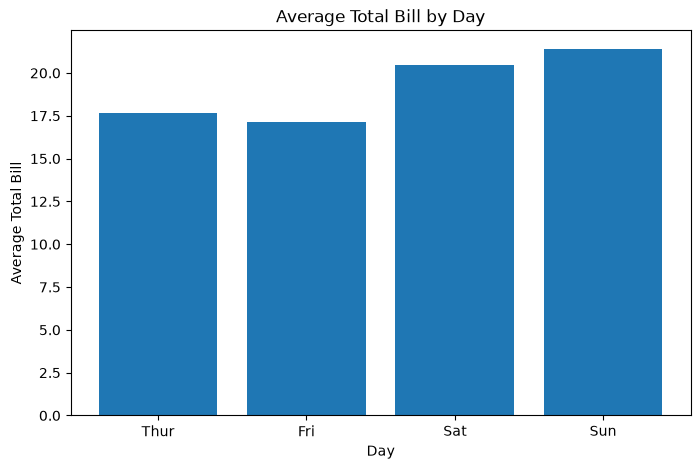

In [22]:
avg_bill_day = df.groupby("day")["total_bill"].mean()

plt.figure(figsize=(8, 5))

plt.bar(avg_bill_day.index, avg_bill_day.values)

plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")

plt.show()

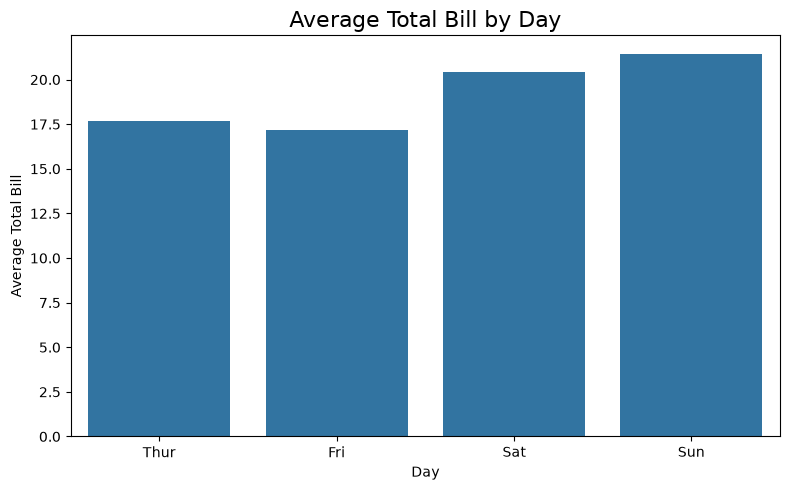

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    errorbar=None
)

plt.title("Average Total Bill by Day", fontsize=16)
plt.xlabel("Day")
plt.ylabel("Average Total Bill")

plt.tight_layout()
plt.show()

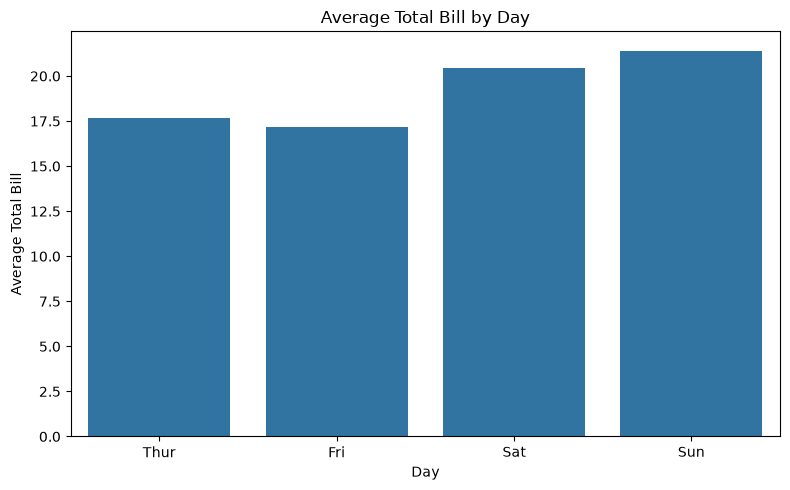

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    errorbar=None
)

plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")

plt.tight_layout()

plt.savefig("../visualizations/bar_chart.png", dpi=300)

plt.show()

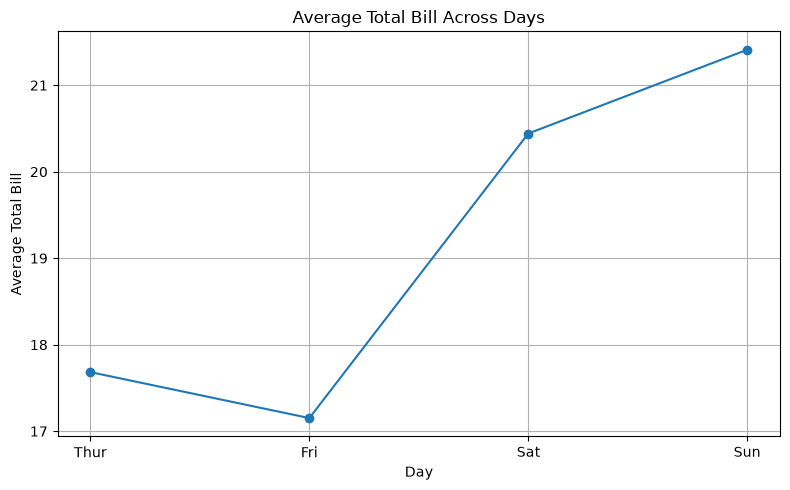

In [25]:
day_order = ["Thur", "Fri", "Sat", "Sun"]

daily_bill = (
    df.groupby("day")["total_bill"]
    .mean()
    .reindex(day_order)
)

plt.figure(figsize=(8, 5))

plt.plot(
    daily_bill.index,
    daily_bill.values,
    marker="o"
)

plt.title("Average Total Bill Across Days")
plt.xlabel("Day")
plt.ylabel("Average Total Bill")

plt.grid(True)

plt.tight_layout()

plt.savefig("../visualizations/line_chart.png", dpi=300)

plt.show()

In [26]:
time_counts = df["time"].value_counts()

time_counts

time
Dinner    176
Lunch      68
Name: count, dtype: int64

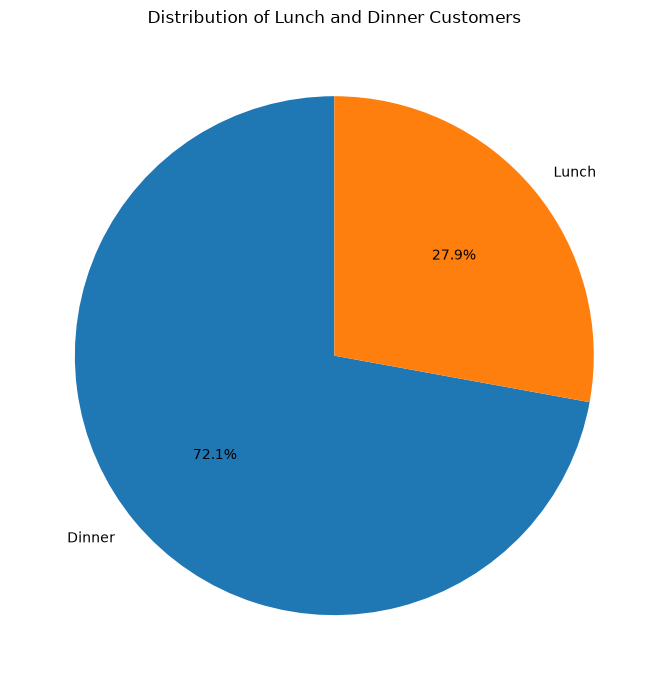

In [27]:
plt.figure(figsize=(7, 7))

plt.pie(
    time_counts.values,
    labels=time_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Lunch and Dinner Customers")

plt.tight_layout()

plt.savefig("../visualizations/pie_chart.png", dpi=300)

plt.show()

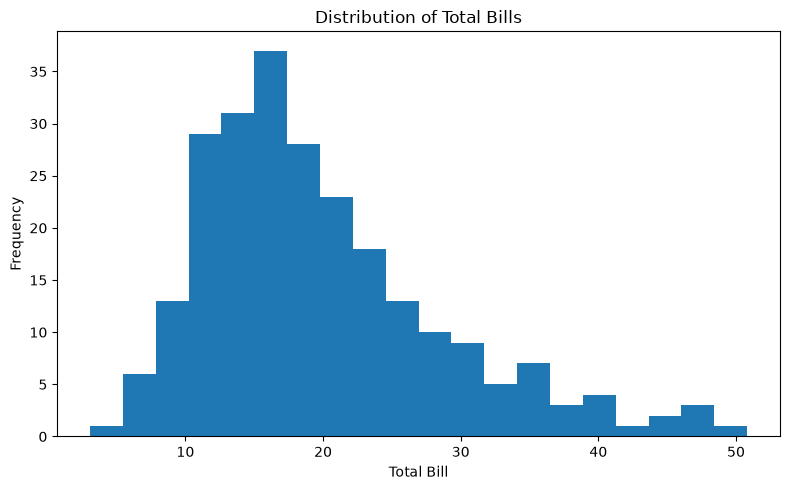

In [28]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["total_bill"],
    bins=20
)

plt.title("Distribution of Total Bills")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig("../visualizations/histogram.png", dpi=300)

plt.show()

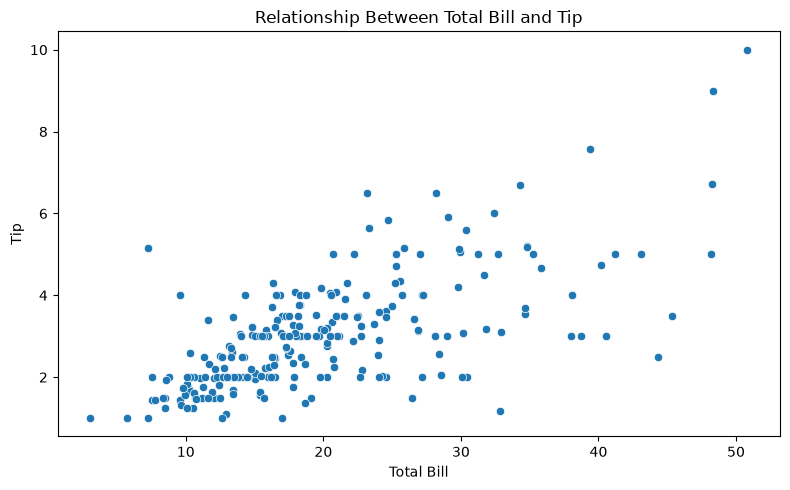

In [29]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip"
)

plt.title("Relationship Between Total Bill and Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.tight_layout()

plt.savefig("../visualizations/scatter_plot.png", dpi=300)

plt.show()

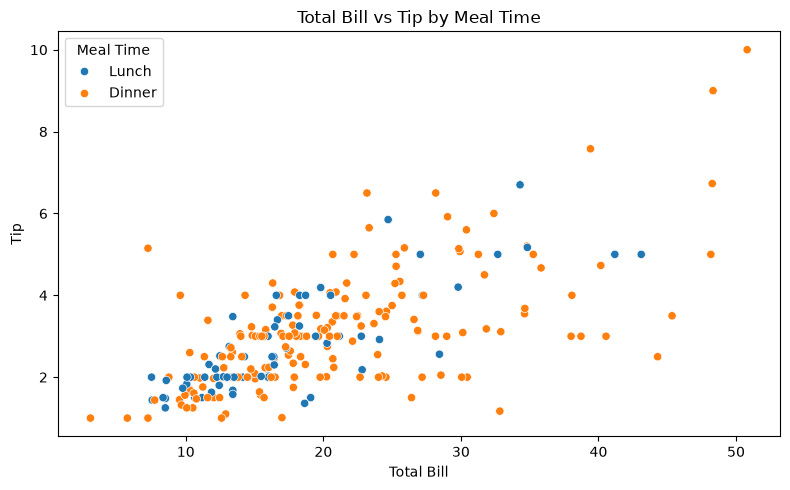

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="time"
)

plt.title("Total Bill vs Tip by Meal Time")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.legend(title="Meal Time")

plt.tight_layout()

plt.show()

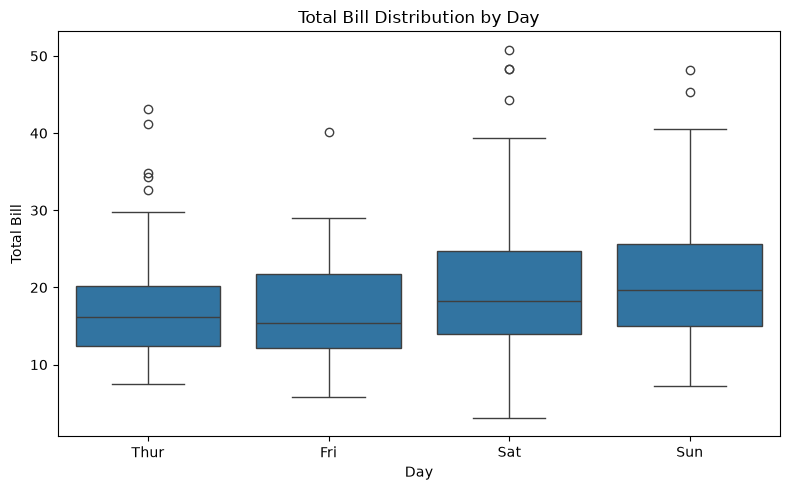

In [31]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="day",
    y="total_bill"
)

plt.title("Total Bill Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")

plt.tight_layout()

plt.show()

In [32]:
df["total_bill"].mean()

np.float64(19.78594262295082)

In [33]:
df["tip"].mean()

np.float64(2.99827868852459)

In [34]:
df.groupby("day")["total_bill"].mean().idxmax()

'Sun'

In [35]:
df.groupby("day")["total_bill"].mean().idxmin()

'Fri'

In [36]:
df["time"].mode()[0]

'Dinner'

In [39]:
df["total_bill"].corr(df["tip"])

np.float64(0.6757341092113641)

## Key Insights

1. The average total bill varies across different days of the week.

2. Dinner accounts for a larger proportion of the observations than lunch.

3. The histogram shows the distribution of customer bills and indicates that most bills fall within a relatively moderate range.

4. The scatter plot shows a positive relationship between total bill and tip, indicating that larger bills generally tend to be associated with higher tips.

5. The visualization of bills by day helps identify which days have relatively higher average spending.